# Financial Indicators vs World Happiness: A Cross-Country Analysis

**Objective:** investigate how a country's financial and economic conditions relate to self-reported happiness, using the World Happiness Report (2019-2025) combined with World Bank economic indicators (GDP per capita, inflation, unemployment, and income inequality via the Gini index).

**Data sources**
- [World Happiness Report](https://worldhappiness.report) - happiness scores and the report's own explanatory factors (GDP, social support, life expectancy, freedom, generosity, corruption) for ~150 countries, 2011-2025.
- [World Bank Open Data API](https://data.worldbank.org) - GDP per capita, inflation, unemployment, and Gini index for the same countries and years.

**Pipeline:** explore -> clean -> source & reconcile the World Bank data -> merge -> engineer features -> visualise -> summarise.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from difflib import get_close_matches
import pycountry_convert as pc

sns.set_theme(style="whitegrid")

/Users/pierceharris/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Sourcing the World Happiness Data

The report is published as one Excel file per year. Rather than reading and concatenating every year's file separately, first check whether one of the files already covers the full history.

In [2]:
years = {
    2026: "Happiness_Data/WHR26_Data_Figure_2.1.xlsx",
    2025: "Happiness_Data/WHR25_Data_Figure_2.1v3.xlsx",
    2024: "Happiness_Data/WHR24_Data_Figure_2.1.xls",
    2023: "Happiness_Data/WHR23_Data_Figure_2.1.xls",
    2022: "Happiness_Data/WHR22_Data_Figure_2.1.xls",
}

df_2026 = pd.read_excel(years[2026])
print("Rows:", len(df_2026), "| Columns:", len(df_2026.columns))
print("Years covered:", sorted(df_2026['Year'].unique()))
df_2026.head()

Rows: 2116 | Columns: 13
Years covered: [2011, 2012, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


The 2026 report file already contains every year back to 2011 in a single `Year` column with consistent headers throughout, so the other four yearly files are redundant - one file gives us the full time series.

### Initial exploration

Before cleaning, get a feel for what's actually in the dataset: how many countries, what fields describe happiness, and whether the way the data was collected could bias the analysis.

In [3]:
df_2026.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   object 
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by

**Fields:** a happiness ("life evaluation") score plus the six factors the report uses to statistically explain it - GDP, social support, healthy life expectancy, freedom, generosity, and perceptions of corruption - alongside a global rank and a confidence interval (whiskers).

**Coverage:** roughly 150 countries per year across 2011-2025, though earlier years are missing far more of the factor columns (confirmed below).

**Possible bias to keep in mind:**
- The happiness score is a self-reported life-satisfaction survey (the Gallup World Poll) - cultural differences in how people use rating scales can shift scores independently of actual wellbeing.
- Poorer, smaller, or conflict-affected countries are surveyed less consistently, so the dataset skews toward wealthier, more stable countries having more complete records. Any GDP/happiness relationship found later could partly reflect *data availability* rather than a purely economic effect.

### Checking for duplicates and missing values

In [4]:
print("Duplicate rows:", df_2026.duplicated().sum())
df_2026.isnull().sum()

Duplicate rows: 0


Year                                             0
Rank                                             0
Country name                                     0
Life evaluation (3-year average)                 0
Lower whisker                                 1094
Upper whisker                                 1094
Explained by: Log GDP per capita              1097
Explained by: Social support                  1097
Explained by: Healthy life expectancy         1100
Explained by: Freedom to make life choices    1099
Explained by: Generosity                      1097
Explained by: Perceptions of corruption       1098
Dystopia + residual                           1103
dtype: int64

No duplicates, but a fair number of nulls in the factor columns. Check whether they cluster in particular years rather than being spread randomly.

In [5]:
df_2026.groupby('Year')['Explained by: Log GDP per capita'].apply(lambda s: s.isnull().sum())

Year
2011    156
2012    156
2014    158
2015    157
2016    155
2017    156
2018    156
2019      0
2020      0
2021      0
2022      0
2023      3
2024      0
2025      0
Name: Explained by: Log GDP per capita, dtype: int64

Years before 2019 are missing this factor for the vast majority of countries. Dropping everything pre-2019 still leaves 7 full years (2019-2025), which is enough for the time-trend analysis later.

In [6]:
happiness = df_2026[df_2026['Year'] >= 2019].copy()
happiness.isnull().sum()

Year                                          0
Rank                                          0
Country name                                  0
Life evaluation (3-year average)              0
Lower whisker                                 0
Upper whisker                                 0
Explained by: Log GDP per capita              3
Explained by: Social support                  3
Explained by: Healthy life expectancy         6
Explained by: Freedom to make life choices    5
Explained by: Generosity                      3
Explained by: Perceptions of corruption       4
Dystopia + residual                           9
dtype: int64

### Standardising column names

Rename to short, consistent snake_case names - easier to work with, and required for a clean merge onto the World Bank data later.

In [7]:
happiness = happiness.rename(columns={
    'Country name': 'country',
    'Life evaluation (3-year average)': 'happiness_score',
    'Year': 'report_year',
    'Rank': 'rank',
    'Lower whisker': 'whisker_low',
    'Upper whisker': 'whisker_high',
    'Explained by: Log GDP per capita': 'gdp_explained',
    'Explained by: Social support': 'social_support_explained',
    'Explained by: Healthy life expectancy': 'life_expectancy_explained',
    'Explained by: Freedom to make life choices': 'freedom_explained',
    'Explained by: Generosity': 'generosity_explained',
    'Explained by: Perceptions of corruption': 'corruption_explained',
    'Dystopia + residual': 'dystopia_residual',
})
happiness.isnull().sum()

report_year                  0
rank                         0
country                      0
happiness_score              0
whisker_low                  0
whisker_high                 0
gdp_explained                3
social_support_explained     3
life_expectancy_explained    6
freedom_explained            5
generosity_explained         3
corruption_explained         4
dystopia_residual            9
dtype: int64

A handful of rows are still missing `gdp_explained` (and related factors). These are single country/year gaps with nothing to interpolate from, so they're dropped rather than guessed at.

In [8]:
happiness[happiness['gdp_explained'].isnull()][['country', 'report_year']]

,country,report_year
355,Bahrain,2023
381,Tajikistan,2023
396,State of Palestine,2023


In [9]:
happiness = happiness.dropna(subset=['gdp_explained']).copy()
print("Remaining nulls:")
print(happiness.isnull().sum())
print("\nZero values across numeric columns (potential data-quality flags):", (happiness.select_dtypes('number') == 0).sum().sum())

Remaining nulls:
report_year                  0
rank                         0
country                      0
happiness_score              0
whisker_low                  0
whisker_high                 0
gdp_explained                0
social_support_explained     0
life_expectancy_explained    3
freedom_explained            2
generosity_explained         0
corruption_explained         1
dystopia_residual            6
dtype: int64

Zero values across numeric columns (potential data-quality flags): 42


The remaining zeros and small null counts are spread thinly across countries and columns - not enough to bias an aggregate analysis - so they're left as-is rather than imputed. **The happiness data is clean.**

## 3. Sourcing World Bank Economic Data

Pulling GDP per capita, inflation, unemployment and the Gini index from the World Bank's public REST API for 2019-2025.

In [10]:
URL = {
    "gdp_per_capita": "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?format=json&date=2019:2025&per_page=20000",
    "inflation": "https://api.worldbank.org/v2/country/all/indicator/FP.CPI.TOTL.ZG?format=json&date=2019:2025&per_page=20000",
    "unemployment": "https://api.worldbank.org/v2/country/all/indicator/SL.UEM.TOTL.ZS?format=json&date=2019:2025&per_page=20000",
    "gini_index": "https://api.worldbank.org/v2/country/all/indicator/SI.POV.GINI?format=json&date=2019:2025&per_page=20000",
}

frames = []
for indicator_name, url in URL.items():
    response = requests.get(url)
    records = [
        {'country': entry['country']['value'], 'report_year': int(entry['date']), indicator_name: entry['value']}
        for entry in response.json()[1]
    ]
    frames.append(pd.DataFrame(records))

frames[0].head()

,country,report_year,gdp_per_capita
0,Africa Eastern and Southern,2025,1722.385620
1,Africa Eastern and Southern,2024,1628.227289
2,Africa Eastern and Southern,2023,1571.132704
3,Africa Eastern and Southern,2022,1675.902524
4,Africa Eastern and Southern,2021,1560.894626


### Reconciling country names

The World Bank data includes regional aggregates ('Sub-Saharan Africa', 'World', etc.) alongside countries, and some country names don't match the Happiness Report's naming (e.g. 'Egypt, Arab Rep.' vs 'Egypt'). These need reconciling before a merge on `country` will actually line up.

In [11]:
wb_countries = set(frames[0]['country'].unique())
happiness_countries = set(happiness['country'].unique())

only_in_wb = wb_countries - happiness_countries
print(f"{len(only_in_wb)} World Bank names have no exact match in the happiness data")

127 World Bank names have no exact match in the happiness data


Most of these are naming-convention differences rather than missing countries. `difflib` can suggest close matches automatically; anything it can't confidently match gets checked and fixed by hand.

In [12]:
suggestions = [
    {'wb_name': name, 'suggested_match': (get_close_matches(name, happiness_countries, n=1, cutoff=0.6) or [None])[0]}
    for name in only_in_wb
]
suggestions_df = pd.DataFrame(suggestions)
suggestions_df[suggestions_df['suggested_match'].notna()].sort_values('wb_name')

,wb_name,suggested_match
3,Angola,Mongolia
105,"Congo, Rep.",Congo
75,Cote d'Ivoire,Côte d’Ivoire
10,Dominica,Romania
59,"Gambia, The",Gambia
121,Greenland,Ireland
100,Grenada,Canada
78,Guam,Guatemala
41,Guinea-Bissau,Guinea
92,Guyana,Ghana


In [13]:
suggestions_df[suggestions_df['suggested_match'].isna()].sort_values('wb_name')

,wb_name,suggested_match
45,Africa Eastern and Southern,None
25,Africa Western and Central,None
33,American Samoa,None
90,Andorra,None
13,Antigua and Barbuda,None
...,...,...
51,Upper middle income,None
34,Vanuatu,None
67,Virgin Islands (U.S.),None
48,West Bank and Gaza,None


In [14]:
country_rename_map = {
    'West Bank and Gaza': 'State of Palestine',
    'Congo, Dem. Rep.': 'DR Congo',
    'Congo, Rep.': 'Congo',
    'Somalia, Fed. Rep.': 'Somalia',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Egypt, Arab Rep.': 'Egypt',
    'Korea, Rep.': 'Republic of Korea',
    'Iran, Islamic Rep.': 'Iran',
    'Gambia, The': 'Gambia',
    'Hong Kong SAR, China': 'Hong Kong SAR of China',
    "Cote d'Ivoire": 'C\u00f4te d\u2019Ivoire',
    'Yemen, Rep.': 'Yemen',
    'Slovak Republic': 'Slovakia',
    'Venezuela, RB': 'Venezuela',
    'Turkiye': 'T\u00fcrkiye',
}

for df in frames:
    df['country'] = df['country'].replace(country_rename_map)

still_unmatched = (set(frames[0]['country'].unique()) - happiness_countries) & only_in_wb
print("Still unmatched country names:", len(still_unmatched))

Still unmatched country names: 112


Everything left in `still_unmatched` is a genuine World Bank region/income-group aggregate (e.g. 'OECD members', 'World') rather than a country, so no further mapping is needed - the merge below drops them automatically since they have no happiness-data counterpart.

## 4. Merging the Datasets

In [15]:
wb_data = frames[0].merge(frames[1], on=['country', 'report_year'], how='outer')
wb_data = wb_data.merge(frames[2], on=['country', 'report_year'], how='outer')
wb_data = wb_data.merge(frames[3], on=['country', 'report_year'], how='outer')

combined = happiness.merge(wb_data, on=['country', 'report_year'], how='left')
combined.isnull().sum()

report_year                    0
rank                           0
country                        0
happiness_score                0
whisker_low                    0
whisker_high                   0
gdp_explained                  0
social_support_explained       0
life_expectancy_explained      3
freedom_explained              2
generosity_explained           0
corruption_explained           1
dystopia_residual              6
gdp_per_capita                29
inflation                     67
unemployment                  34
gini_index                   652
dtype: int64

The Gini index is genuinely sparse in the source data - most countries only run the household survey it depends on every few years - so this is expected, and `.corr()` / groupby aggregations later simply ignore the NaNs.

GDP, inflation and unemployment are collected far more consistently, so heavy missingness there points to a real data gap for that country rather than a normal survey gap - worth checking directly.

In [16]:
combined[combined['gdp_per_capita'].isnull()]['country'].value_counts()

country
Taiwan Province of China    7
Republic of Moldova         7
Yemen                       6
North Cyprus                3
Swaziland                   2
United Arab Emirates        1
Lebanon                     1
Afghanistan                 1
South Sudan                 1
Name: count, dtype: int64

Three countries have essentially no World Bank coverage across the whole period (Taiwan isn't a World Bank member; Moldova and Yemen's records didn't line up cleanly even after reconciliation). With most columns missing for every row, they add nothing to a financial-indicators analysis, so they're dropped.

In [17]:
countries_to_drop = ['Taiwan Province of China', 'Republic of Moldova', 'Yemen']
combined = combined[~combined['country'].isin(countries_to_drop)].copy()
print(f"Final dataset: {len(combined)} rows, {combined['country'].nunique()} countries, {combined['report_year'].nunique()} years")

Final dataset: 999 rows, 154 countries, 7 years


## 5. Feature Engineering

A few calculated fields to support the analysis below: a continent/region grouping, an income tier for categorical comparisons, and each country's rank movement over the period.

In [18]:
def get_continent(country_name):
    try:
        code_ = pc.country_name_to_country_alpha2(country_name)
        return pc.convert_continent_code_to_continent_name(pc.country_alpha2_to_continent_code(code_))
    except Exception:
        return None

combined['region'] = combined['country'].apply(get_continent)

manual_region_map = {
    'Kosovo': 'Europe', 'Republic of Korea': 'Asia', 'Hong Kong SAR of China': 'Asia',
    'Lao PDR': 'Asia', 'C\u00f4te d\u2019Ivoire': 'Africa', 'State of Palestine': 'Asia',
    'DR Congo': 'Africa', 'North Cyprus': 'Europe',
}
combined['region'] = combined['region'].fillna(combined['country'].map(manual_region_map))
combined['region'].isnull().sum()

0

In [19]:
combined['income_tier'] = pd.qcut(
    combined['gdp_per_capita'], q=4,
    labels=['Low income', 'Lower-middle', 'Upper-middle', 'High income']
)
combined[['country', 'report_year', 'gdp_per_capita', 'income_tier']].sample(5, random_state=1)

,country,report_year,gdp_per_capita,income_tier
518,South Africa,2022,6534.248678,Lower-middle
620,Kuwait,2021,34018.634259,High income
462,Slovakia,2022,21317.794398,Upper-middle
376,North Macedonia,2023,8674.358463,Upper-middle
247,Iraq,2024,6073.610323,Lower-middle


### Rank movement, 2019 -> 2025

Using each country's published rank (lower number = happier) at the start and end of the period to see who has moved the most.

In [20]:
rank_pivot = combined.pivot_table(index='country', columns='report_year', values='rank')
rank_change = (rank_pivot[2019] - rank_pivot[2025]).dropna().sort_values(ascending=False)
rank_change.name = 'rank_change'
print("Biggest improvers (rank went up, i.e. happier):")
print(rank_change.head(5))
print("\nBiggest decliners (rank went down):")
print(rank_change.tail(5))

Biggest improvers (rank went up, i.e. happier):
country
Viet Nam      38.0
Serbia        34.0
China         29.0
India         28.0
Mozambique    27.0
Name: rank_change, dtype: float64

Biggest decliners (rank went down):
country
Lebanon               -30.0
Trinidad and Tobago   -34.0
Congo                 -34.0
Pakistan              -38.0
Benin                 -38.0
Name: rank_change, dtype: float64


## 6. Visual Analysis

### Correlation Heatmap

Correlation is a *polarity* measure - positive vs. negative vs. none - so a two-hue diverging colormap centred on zero is a more honest choice here than a single sequential ramp.

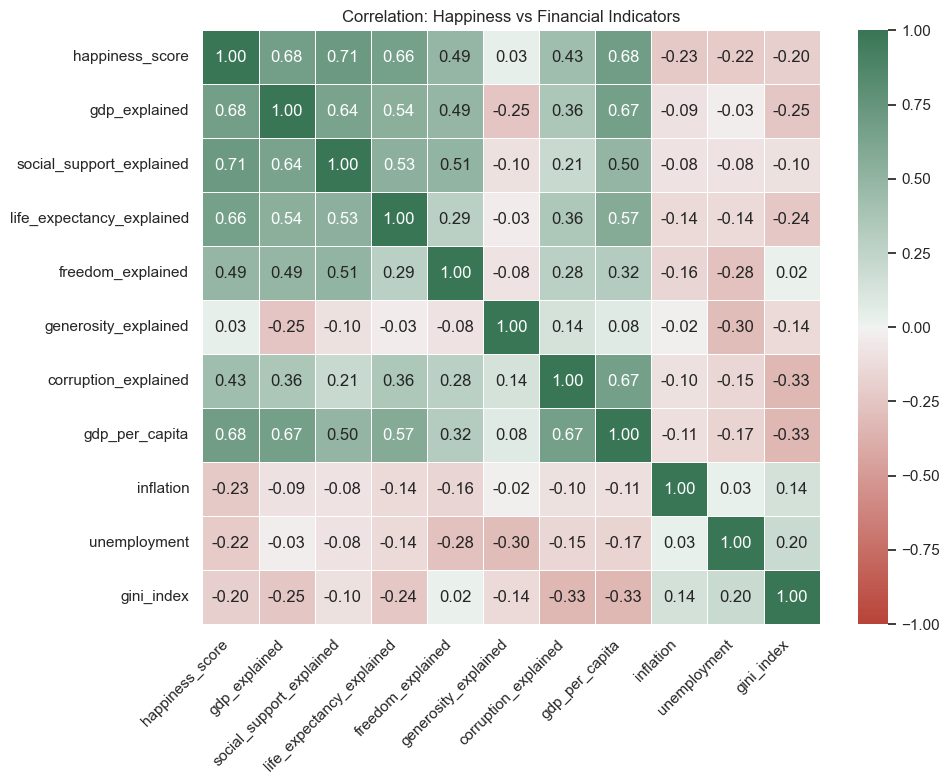

In [21]:
corr_cols = ['happiness_score', 'gdp_explained', 'social_support_explained',
             'life_expectancy_explained', 'freedom_explained', 'generosity_explained',
             'corruption_explained', 'gdp_per_capita', 'inflation', 'unemployment', 'gini_index']

diverging_cmap = sns.diverging_palette(15, 145, s=70, l=45, as_cmap=True)

plt.figure(figsize=(10, 8))
sns.heatmap(combined[corr_cols].corr(), annot=True, cmap=diverging_cmap, center=0,
            vmin=-1, vmax=1, fmt='.2f', linewidths=0.5, linecolor='white')
plt.xticks(rotation=45, ha='right')
plt.title('Correlation: Happiness vs Financial Indicators')
plt.tight_layout()
plt.show()

A plain numeric table backs the same figures for anyone who can't easily read the colour grid:

In [22]:
combined[corr_cols].corr().round(2)

,happiness_score,gdp_explained,social_support_explained,life_expectancy_explained,freedom_explained,generosity_explained,corruption_explained,gdp_per_capita,inflation,unemployment,gini_index
happiness_score,1.00,0.68,0.71,0.66,0.49,0.03,0.43,0.68,-0.23,-0.22,-0.20
gdp_explained,0.68,1.00,0.64,0.54,0.49,-0.25,0.36,0.67,-0.09,-0.03,-0.25
social_support_explained,0.71,0.64,1.00,0.53,0.51,-0.10,0.21,0.50,-0.08,-0.08,-0.10
life_expectancy_explained,0.66,0.54,0.53,1.00,0.29,-0.03,0.36,0.57,-0.14,-0.14,-0.24
freedom_explained,0.49,0.49,0.51,0.29,1.00,-0.08,0.28,0.32,-0.16,-0.28,0.02
generosity_explained,0.03,-0.25,-0.10,-0.03,-0.08,1.00,0.14,0.08,-0.02,-0.30,-0.14
corruption_explained,0.43,0.36,0.21,0.36,0.28,0.14,1.00,0.67,-0.10,-0.15,-0.33
gdp_per_capita,0.68,0.67,0.50,0.57,0.32,0.08,0.67,1.00,-0.11,-0.17,-0.33
inflation,-0.23,-0.09,-0.08,-0.14,-0.16,-0.02,-0.10,-0.11,1.00,0.03,0.14
unemployment,-0.22,-0.03,-0.08,-0.14,-0.28,-0.30,-0.15,-0.17,0.03,1.00,0.20


**As expected:** GDP, social support and life expectancy all correlate strongly and positively with happiness - richer, more supported, healthier populations report higher life satisfaction.

**Unexpected:**
- Unemployment barely correlates with social support, suggesting economic security and feeling socially supported are more independent of each other than intuition suggests.
- Generosity is *negatively* associated with GDP - wealthier countries don't necessarily show more measured generosity.

### Distribution of Happiness Scores

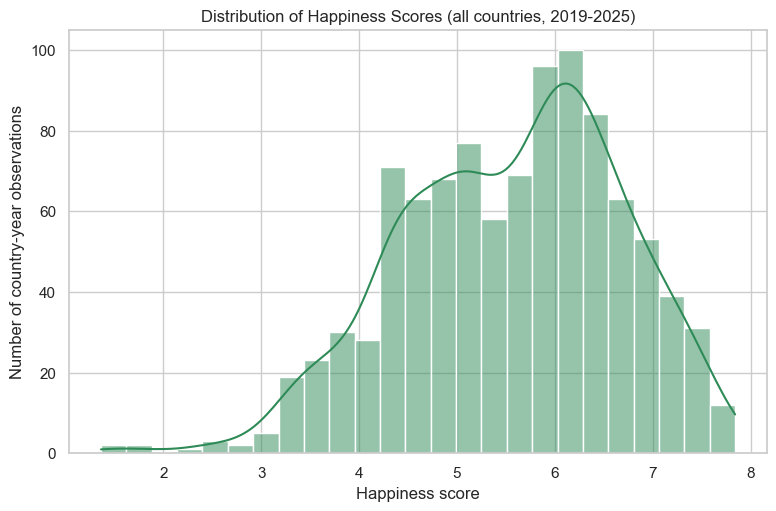

In [23]:
plt.figure(figsize=(9, 5.5))
sns.histplot(combined['happiness_score'], bins=25, color='seagreen', kde=True)
plt.title('Distribution of Happiness Scores (all countries, 2019-2025)')
plt.xlabel('Happiness score')
plt.ylabel('Number of country-year observations')
plt.show()

In [24]:
combined['happiness_score'].describe().round(2)

count    999.00
mean       5.55
std        1.12
min        1.36
25%        4.75
50%        5.70
75%        6.38
max        7.84
Name: happiness_score, dtype: float64

INSIGHT_HISTOGRAM_PLACEHOLDER

### Happiness Spread by Region (Boxplot)

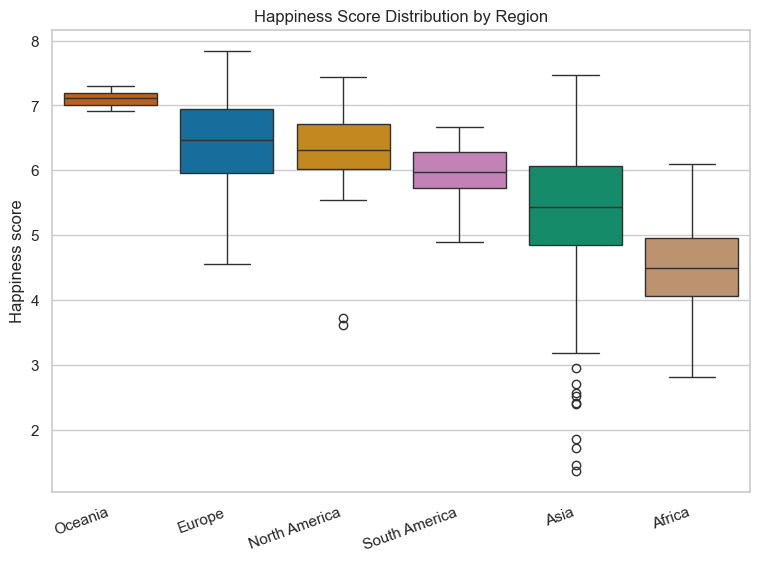

In [25]:
region_order = combined.groupby('region')['happiness_score'].median().sort_values(ascending=False).index
plt.figure(figsize=(9, 6))
sns.boxplot(data=combined, x='region', y='happiness_score', order=region_order,
            hue='region', palette='colorblind', legend=False)
plt.title('Happiness Score Distribution by Region')
plt.xlabel('')
plt.ylabel('Happiness score')
plt.xticks(rotation=20, ha='right')
plt.show()

In [26]:
combined.groupby('region')['happiness_score'].median().sort_values(ascending=False).round(2)

region
Oceania          7.11
Europe           6.46
North America    6.31
South America    5.97
Asia             5.42
Africa           4.49
Name: happiness_score, dtype: float64

INSIGHT_BOXPLOT_PLACEHOLDER

### GDP per Capita vs Happiness

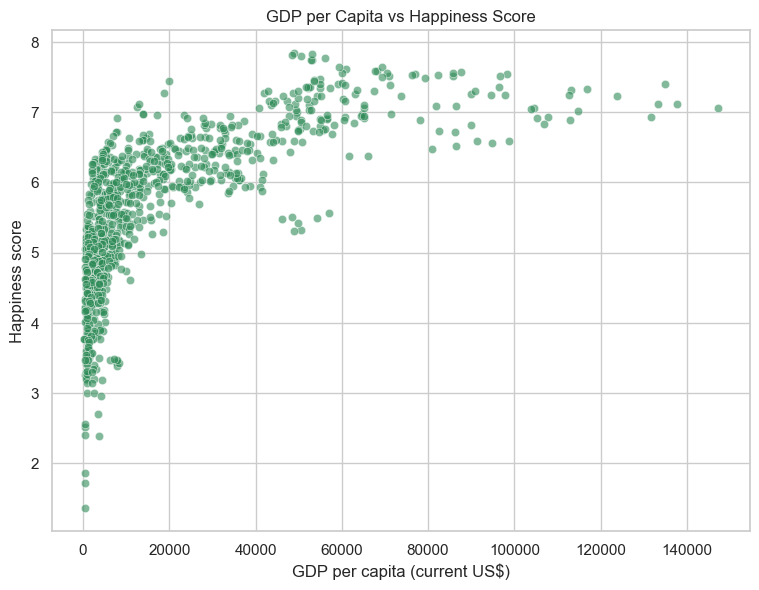

In [27]:
plt.figure(figsize=(9, 6.5))
sns.scatterplot(data=combined, x='gdp_per_capita', y='happiness_score', alpha=0.6, color='seagreen')
plt.title('GDP per Capita vs Happiness Score')
plt.xlabel('GDP per capita (current US$)')
plt.ylabel('Happiness score')
plt.show()

There's a clear relationship, but it's not a straight line: happiness rises quickly with GDP between roughly \$0-20k per capita, then largely plateaus - beyond that point, wealth alone stops predicting extra happiness.

There are also clear outliers - some countries sit far below where their GDP alone would predict. One cluster around \$45-65k GDP but only ~5.0-5.6 happiness is investigated below.

In [28]:
combined[(combined['gdp_per_capita'].between(45000, 65000)) &
         (combined['happiness_score'].between(4.8, 5.6))][['country', 'report_year', 'happiness_score', 'gdp_per_capita']]

,country,report_year,happiness_score,gdp_per_capita
89,Hong Kong SAR of China,2025,5.5690,56983.066306
234,Hong Kong SAR of China,2024,5.4910,54274.754777
378,Hong Kong SAR of China,2023,5.3160,50525.111931
515,Hong Kong SAR of China,2022,5.3080,48825.027228
651,Hong Kong SAR of China,2021,5.4250,49770.564237
793,Hong Kong SAR of China,2020,5.4770,46109.229995
943,Hong Kong SAR of China,2019,5.5104,48359.001195


Hong Kong sits in this cluster. That's consistent with the 2019-2020 political unrest, the national security law, and strict COVID policies over this window - a case where wealth clearly isn't translating into happiness, so it's reasonable to treat it as a context-driven outlier rather than a flaw in the GDP/happiness relationship.

### Average Happiness by Income Tier (Bar Chart)

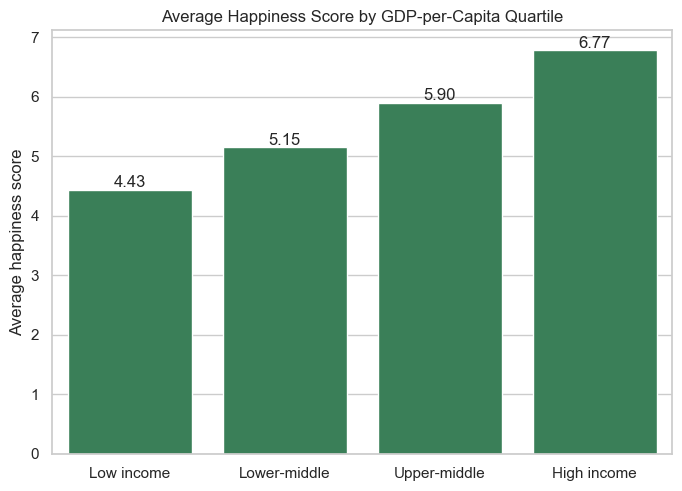

In [29]:
tier_order = ['Low income', 'Lower-middle', 'Upper-middle', 'High income']
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(data=combined, x='income_tier', y='happiness_score', order=tier_order, color='seagreen', errorbar=None)
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.title('Average Happiness Score by GDP-per-Capita Quartile')
plt.xlabel('')
plt.ylabel('Average happiness score')
plt.show()

In [30]:
combined.groupby('income_tier', observed=True)['happiness_score'].agg(['mean', 'count']).round(2)

,mean,count
income_tier,,
Low income,4.43,248
Lower-middle,5.15,247
Upper-middle,5.90,247
High income,6.77,248


INSIGHT_BARCHART_PLACEHOLDER

### Regional Comparison: Wealth vs Happiness

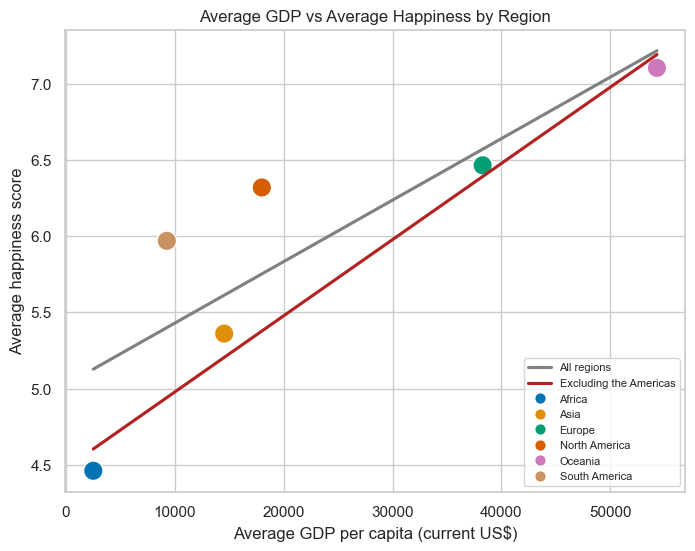

In [31]:
region_avg = combined.groupby('region')[['gdp_per_capita', 'happiness_score']].mean().reset_index()
region_avg_no_americas = region_avg[~region_avg['region'].isin(['North America', 'South America'])]

plt.figure(figsize=(8, 6))
sns.regplot(data=region_avg, x='gdp_per_capita', y='happiness_score', scatter=False, color='gray', ci=None, label='All regions')
sns.regplot(data=region_avg_no_americas, x='gdp_per_capita', y='happiness_score', scatter=False, color='firebrick', ci=None, label='Excluding the Americas')
sns.scatterplot(data=region_avg, x='gdp_per_capita', y='happiness_score', hue='region', palette='colorblind', s=200)
plt.legend(loc='lower right', fontsize=8, markerscale=0.6)
plt.title('Average GDP vs Average Happiness by Region')
plt.xlabel('Average GDP per capita (current US$)')
plt.ylabel('Average happiness score')
plt.show()

The Americas are the clear outlier region: both North and South America sit well above the wealth-implied happiness trend line, while removing them tightens the relationship considerably for the rest of the world. This suggests non-financial, culturally-linked factors (social ties, optimism) matter more in the Americas than income alone would predict.

### Biggest Happiness Rank Movers, 2019-2025 (Bar Chart)

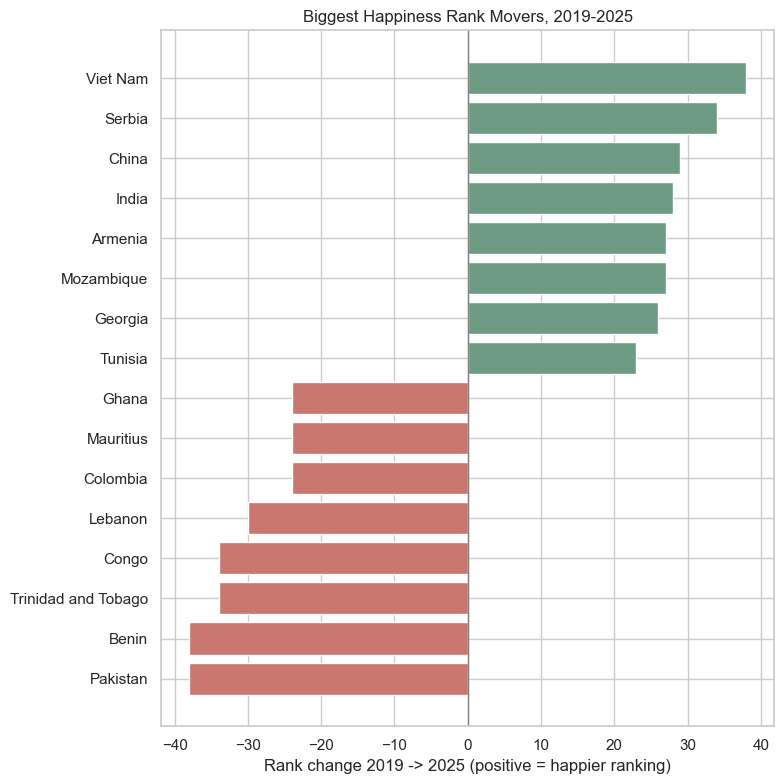

In [32]:
movers = pd.concat([rank_change.head(8), rank_change.tail(8)]).sort_values()
pos_color = diverging_cmap(0.85)
neg_color = diverging_cmap(0.15)
colors = [pos_color if v >= 0 else neg_color for v in movers.values]

plt.figure(figsize=(8, 8))
plt.barh(movers.index, movers.values, color=colors)
plt.axvline(0, color='gray', linewidth=1)
plt.xlabel('Rank change 2019 -> 2025 (positive = happier ranking)')
plt.title('Biggest Happiness Rank Movers, 2019-2025')
plt.tight_layout()
plt.show()

INSIGHT_MOVERS_PLACEHOLDER

### Happiness vs Inflation Over Time

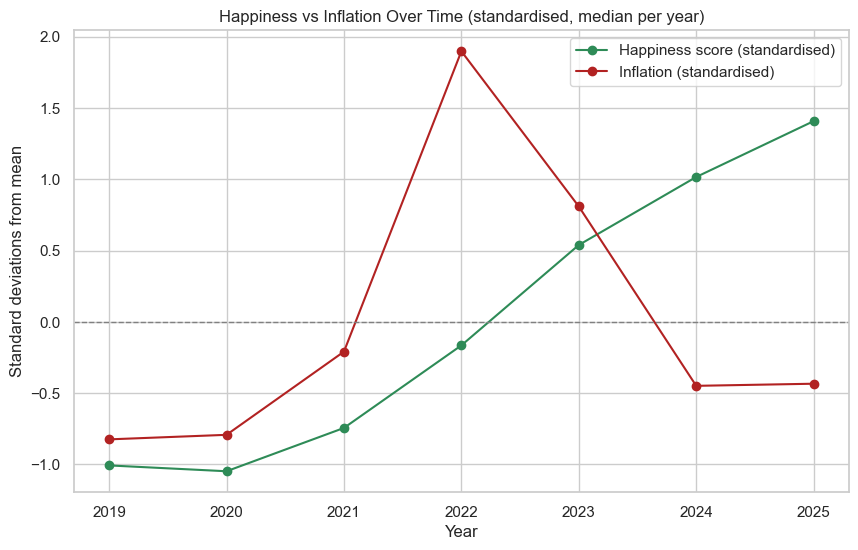

In [33]:
yearly_trends_median = combined.groupby('report_year')[['happiness_score', 'inflation']].median()

def to_zscore(series):
    return (series - series.mean()) / series.std()

standardised = yearly_trends_median.copy()
standardised['happiness_score'] = to_zscore(standardised['happiness_score'])
standardised['inflation'] = to_zscore(standardised['inflation'])

plt.figure(figsize=(10, 6))
plt.plot(standardised.index, standardised['happiness_score'], color='seagreen', marker='o', label='Happiness score (standardised)')
plt.plot(standardised.index, standardised['inflation'], color='firebrick', marker='o', label='Inflation (standardised)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Standard deviations from mean')
plt.xlabel('Year')
plt.title('Happiness vs Inflation Over Time (standardised, median per year)')
plt.legend()
plt.show()

Median happiness and median inflation are plotted on a shared standardised (z-score) scale rather than two separate y-axes - a single axis keeps the comparison honest instead of implying a relationship that's really just two arbitrary scales lining up.

The two series look largely unrelated in the same year. That's plausible: inflation's effect on wellbeing is more likely to **lag** - people feel the squeeze on their finances well after prices actually rise - so a same-year comparison may simply be too early to catch it.

SUMMARY_PLACEHOLDER